In [1]:
import pandas as pd
pd.set_option("display.max_columns", 24)

# Importing the data

In [2]:
df_amazon = pd.read_csv(r"/Users/developer/Documents/Current Project/Python/DevArena /DevArena-Week-6/data/Amazon Sale Report.csv")
df_amazon.set_index("index", inplace=True)
df_amazon.head()

/var/folders/p0/_bzvcc_50zq0rsj23x4gfbm00000gp/T/ipykernel_2537/219989868.py:1: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  df_amazon = pd.read_csv(r"/Users/developer/Documents/Current Project/Python/DevArena /DevArena-Week-6/data/Amazon Sale Report.csv")


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
index,,,,,,,,,,,,,,,,,,,,,,,
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


# Preprocessing

In [3]:
df_amazon.isnull().sum()

Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

<b><p>
First, we will handle the null values in the Courier Status.
</b>

In [4]:
# df_amazon[ (df_amazon["Courier Status"].isna()) & ~(df_amazon["Amount"].isna()) & (df_amazon["Status"]=="Cancelled") ]
df_amazon[ (df_amazon["Status"]=='Shipped - Delivered to Buyer') ].shape

(28769, 23)

In [5]:
df_amazon["Status"].unique().tolist()

['Cancelled',
 'Shipped - Delivered to Buyer',
 'Shipped',
 'Shipped - Returned to Seller',
 'Shipped - Rejected by Buyer',
 'Shipped - Lost in Transit',
 'Shipped - Out for Delivery',
 'Shipped - Returning to Seller',
 'Shipped - Picked Up',
 'Pending',
 'Pending - Waiting for Pick Up',
 'Shipped - Damaged',
 'Shipping']

<p>
To account for the analysis of sales we will only take the orders that have ben <b>successfully shipped to buyer</b>, <b>out for dilevery</b>, <b>picked up</b>. 


In [6]:
df_amazon_sales_completed = df_amazon[ (df_amazon["Status"]=='Shipped - Delivered to Buyer') | 
                                        (df_amazon["Status"]=='Shipped') |
                                        (df_amazon["Status"]=='Shipped - Out for Delivery') | 
                                        (df_amazon["Status"]=='Shipped - Picked Up')]
df_amazon_sales_completed

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
index,,,,,,,,,,,,,,,,,,,,,,,
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.0,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.0,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.0,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
5,404-1490984-4578765,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,XL,B08YN7XDSG,Shipped,1,INR,824.0,GHAZIABAD,UTTAR PRADESH,201102.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
6,408-5748499-6859555,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,L,B08CMHNWBN,Shipped,1,INR,653.0,CHANDIGARH,CHANDIGARH,160036.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128970,406-6001380-7673107,05-31-22,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,kurta,XL,B098112V2V,Shipped,1,INR,517.0,HYDERABAD,TELANGANA,500013.0,IN,NaN,False,NaN,False
128971,402-9551604-7544318,05-31-22,Shipped,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,Set,M,B09VC6KHX8,Shipped,1,INR,999.0,GURUGRAM,HARYANA,122004.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
128972,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157-DR-XXL,Western Dress,XXL,B0982YZ51B,Shipped,1,INR,690.0,HYDERABAD,TELANGANA,500049.0,IN,NaN,False,NaN,False


In [7]:
df_amazon_sales_not_completed = df_amazon[ (df_amazon["Status"]=='Shipped - Rejected by Buyer') |
                                        (df_amazon["Status"]=='Shipped - Lost in Transit') | 
                                        (df_amazon["Status"]=='Shipped - Returning to Seller') |
                                        (df_amazon["Status"]=='Shipped - Damaged')
                                    ]
df_amazon_sales_not_completed

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
index,,,,,,,,,,,,,,,,,,,,,,,
433,407-7607527-1189964,04-30-22,Shipped - Rejected by Buyer,Merchant,Amazon.in,Standard,J0096,J0096-KR-S,kurta,S,B089G356KM,Shipped,1,INR,568.0,RAMANAGARA,KARNATAKA,562159.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
4017,408-3647481-1358717,04-28-22,Shipped - Lost in Transit,Merchant,Amazon.in,Standard,SET304,SET304-KR-DPT-XXL,Set,XXL,B09K3YHSDV,Shipped,1,INR,0.0,BENGALURU,KARNATAKA,560102.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
4023,408-6812579-8773938,04-28-22,Shipped - Lost in Transit,Merchant,Amazon.in,Standard,J0005,J0005-DR-XL,Western Dress,XL,B08B3YB1FR,Shipped,1,INR,0.0,BENGALURU,KARNATAKA,560102.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
4546,402-7273102-2737104,04-27-22,Shipped - Rejected by Buyer,Merchant,Amazon.in,Standard,J0003,J0003-SET-XXL,Set,XXL,B0894XKVH3,Shipped,1,INR,654.0,NASHIK,MAHARASHTRA,422101.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
16633,406-2528038-8442757,04-20-22,Shipped - Returning to Seller,Merchant,Amazon.in,Standard,SET397,SET397-KR-NP-XS,Set,XS,B09RKDH2BT,Shipped,1,INR,1115.0,DULIAJAN,ASSAM,786602.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116134,408-2274713-4795536,06-09-22,Shipped - Returning to Seller,Merchant,Amazon.in,Standard,JNE3721,JNE3721-KR-XL,kurta,XL,B099FDMD6T,Shipped,1,INR,292.0,FERRARGUNJ,ANDAMAN & NICOBAR,744103.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
116284,408-0662582-9807517,06-09-22,Shipped - Returning to Seller,Merchant,Amazon.in,Standard,JNE3907,JNE3907-KR-S,kurta,S,B0B3MPZQRN,Shipped,1,INR,819.0,SILCHAR,ASSAM,788004.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
118103,403-5924643-2805148,06-08-22,Shipped - Returning to Seller,Merchant,Amazon.in,Standard,SET392,SET392-KR-NP-M,Set,M,B09RKFDT7Q,Shipped,1,INR,799.0,NAVI MUMBAI,MAHARASHTRA,400701.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False


I will add the date, time and year columns by splitting from the date column.

In [8]:
df_amazon_sales_completed[["Month", "Day", "Year"]] = df_amazon_sales_completed["Date"].str.split("-", expand=True)
df_amazon_sales_completed.drop(["Date"], axis="columns", inplace=True)

In [9]:
df_amazon_sales_not_completed[["Month", "Day", "Year"]] = df_amazon_sales_not_completed["Date"].str.split("-", expand=True)
df_amazon_sales_not_completed.drop(["Date"], axis="columns", inplace=True)

Dropping out the unnecessary columns

In [10]:
df_amazon_sales_completed.drop(["promotion-ids", "Unnamed: 22"], axis="columns", inplace=True)

In [11]:
df_amazon_sales_not_completed.drop(["promotion-ids", "Unnamed: 22"], axis="columns", inplace=True)

Filling NULL values in ship-country column. 

In [12]:
df_amazon_sales_completed["ship-country"].unique().tolist()
df_amazon_sales_not_completed["ship-country"].unique().tolist()

['IN']

In [13]:
df_amazon_sales_completed["ship-country"] = df_amazon_sales_completed["ship-country"].fillna("IN")
df_amazon_sales_not_completed["ship-country"] = df_amazon_sales_not_completed["ship-country"].fillna("IN")

In [14]:
df_amazon_sales_completed.drop(["ship-postal-code"], axis="columns", inplace=True)
df_amazon_sales_not_completed.drop(["ship-postal-code"], axis="columns", inplace=True)

In [15]:
df_amazon_sales_completed.dropna(subset=["ship-city", "ship-state"], inplace=True)
df_amazon_sales_not_completed.dropna(subset=["ship-city", "ship-state"], inplace=True)

In [16]:
df_amazon_sales_completed.drop(["currency"], axis="columns", inplace=True)
df_amazon_sales_not_completed.drop(["currency"], axis="columns", inplace=True)

In [17]:
df_amazon_sales_completed.dropna(subset=["Amount"], inplace=True)
df_amazon_sales_not_completed.dropna(subset=["Amount"], inplace=True)

In [18]:
df_amazon_sales_completed.drop(["fulfilled-by", "B2B"], axis="columns", inplace=True)
df_amazon_sales_not_completed.drop(["fulfilled-by", "B2B"], axis="columns", inplace=True)

Rectitfying the value for the states for the 'ship-state' column.

In [19]:
df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "New Delhi" if x == "Delhi" else x
)

df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "Puducherry" if x == "Pondicherry" else x
)

df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "Punjab" if x == "Pb" else x
)

df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "Punjab" if x == "Punjab/Mohali/Zirakpur" else x
)

df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "Nagaland" if x == "Nl" else x
)

df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "Rajasthan" if x == "Rj" else x
)

df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "Rajasthan" if x == "Rajsthan" else x
)

df_amazon_sales_completed["ship-state"] = df_amazon_sales_completed["ship-state"].apply(
    lambda x: "Arunachal Pradesh" if x == "Ar" else x
)

In [20]:
df_amazon_sales_not_completed["ship-state"] = df_amazon_sales_not_completed["ship-state"].apply(
    lambda x: "New Delhi" if x == "Delhi" else x
)

df_amazon_sales_not_completed["ship-state"] = df_amazon_sales_not_completed["ship-state"].apply(
    lambda x: "Puducherry" if x == "Pondicherry" else x
)

df_amazon_sales_not_completed["ship-state"] = df_amazon_sales_not_completed["ship-state"].apply(
    lambda x: "Punjab" if x == "Pb" else x
)

df_amazon_sales_not_completed["ship-state"] = df_amazon_sales_not_completed["ship-state"].apply(
    lambda x: "Punjab" if x == "Punjab/Mohali/Zirakpur" else x
)

df_amazon_sales_not_completed["ship-state"] = df_amazon_sales_not_completed["ship-state"].apply(
    lambda x: "Nagaland" if x == "Nl" else x
)

df_amazon_sales_not_completed["ship-state"] = df_amazon_sales_not_completed["ship-state"].apply(
    lambda x: "Rajasthan" if x == "Rj" else x
)

df_amazon_sales_not_completed["ship-state"] = df_amazon_sales_not_completed["ship-state"].apply(
    lambda x: "Rajasthan" if x == "Rajsthan" else x
)

df_amazon_sales_not_completed["ship-state"] = df_amazon_sales_not_completed["ship-state"].apply(
    lambda x: "Arunachal Pradesh" if x == "Ar" else x
)

In [21]:
df_amazon_sales_completed["ship-state"].unique().tolist()[0:5]

['KARNATAKA', 'MAHARASHTRA', 'TAMIL NADU', 'UTTAR PRADESH', 'CHANDIGARH']

In [22]:
df_amazon_sales_completed.isnull().sum()
df_amazon_sales_not_completed.isnull().sum()

Order ID              0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
Amount                0
ship-city             0
ship-state            0
ship-country          0
Month                 0
Day                   0
Year                  0
dtype: int64

Saving the file

In [23]:
df_amazon_sales_completed.to_csv(r"/Users/developer/Documents/Current Project/Python/DevArena /DevArena-Week-6/data/amazon_final.csv")
df_amazon_sales_not_completed.to_csv(r"/Users/developer/Documents/Current Project/Python/DevArena /DevArena-Week-6/data/notamazon_final.csv")

# Dashboarding

In [24]:
from dash import Dash, html, dcc, callback, Output, Input
import dash_ag_grid as dag
import pandas as pd 
import plotly.express as pex
from matplotlib import pyplot as plt

In [25]:
import seaborn as sns

<b>
Visualizing the distibution of values in columns 'Amount'
</b>

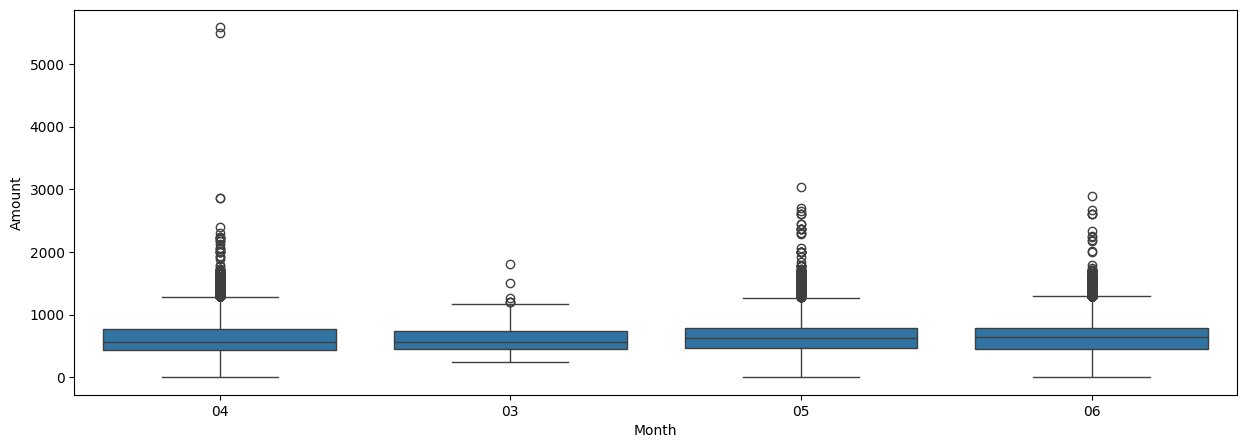

In [26]:
plt.figure(figsize=(15,5))
sns.boxplot(x='Month'
            , y = 'Amount'
            , data= df_amazon_sales_completed)
plt.show()

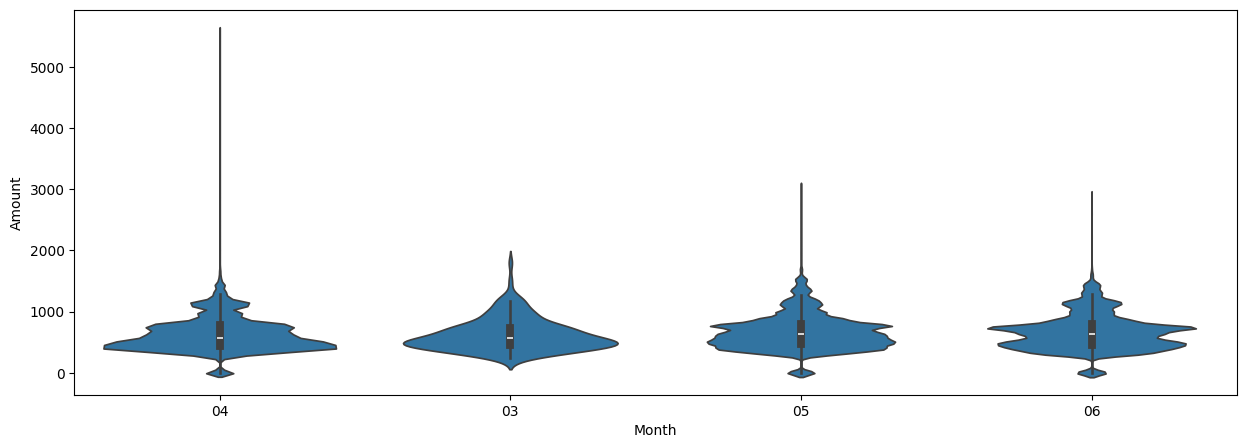

In [27]:
plt.figure(figsize=(15,5))
sns.violinplot(x='Month'
            , y = 'Amount'
            , data= df_amazon_sales_completed)
plt.show()

<b>Plotly visualizations for the above two data ( would be rendered in browser )

In [44]:
fig = pex.violin(data_frame= df_amazon_sales_completed, 
                   x= "Month" ,
                   y= "Amount")
fig.show(renderer="browser")

In [43]:
fig = pex.box(data_frame= df_amazon_sales_completed, 
                   x= "Month" ,
                   y= "Amount")
fig.show(renderer="browser")

<b>
Category Line Plot
</b>

In [30]:
df_category_sales = df_amazon_sales_completed.groupby(["Month", "Category"]).agg(
    monthly_revenue = ("Amount", "sum"), 
    no_orders = ("Order ID", "nunique")
)
df_category_sales

monthly_revenue  no_orders
Month Category                                 
03    Blouse                   280.0          1
      Set                    50905.0         59
      Top                     4511.0          9
      Western Dress           5479.0          6
      kurta                  33008.0         64
04    Blouse                172156.0        342
      Bottom                 58718.0        151
      Ethnic Dress          223663.0        296
      Saree                  49123.0         50
      Set                 13805882.0      15991
      Top                  1653528.0       3281
      Western Dress        2625356.0       3395
      kurta                7075156.0      15240
05    Blouse                142761.0        267
      Bottom                 41089.0        107
      Ethnic Dress          263424.0        377
      Saree                  40190.0         44
      Set                 11294978.0      12724
      Top                  1799831.0       3321
      Western Dress        3866244.0       4860
      kurta                6011595.0      11789
06    Blouse                 94297.0        154
      Bottom                 33065.0         88
      Dupatta                  915.0          2
      Ethnic Dress          228264.0        308
      Saree                  24383.0         28
      Set                  9576384.0      10865
      Top                  1336889.0       2110
      Western Dress        3330932.0       4156
      kurta                5805275.0      11579

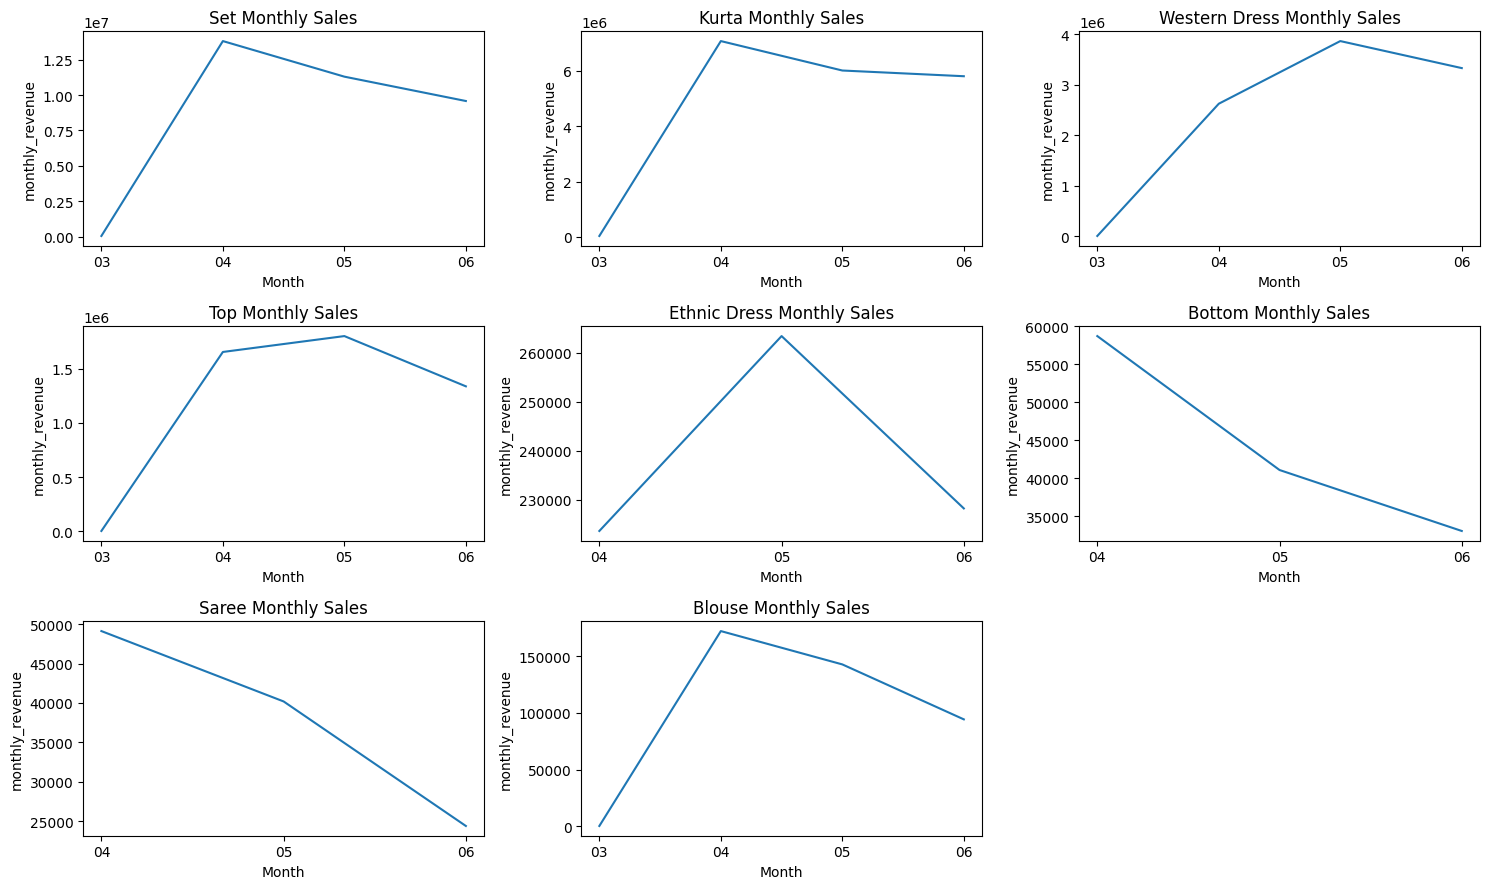

In [32]:
df_set_monthly_sales =   df_category_sales.xs("Set", level="Category")
df_kurta_monthly_sales = df_category_sales.xs("kurta", level="Category")
df_wes_monthly_sales =   df_category_sales.xs("Western Dress", level="Category")
df_top_monthly_sales =   df_category_sales.xs("Top", level="Category")
df_eth_monthly_sales =   df_category_sales.xs("Ethnic Dress", level="Category")
df_bot_monthly_sales =   df_category_sales.xs("Bottom", level="Category")
df_sar_monthly_sales =   df_category_sales.xs("Saree", level="Category")
df_blo_monthly_sales =   df_category_sales.xs("Blouse", level="Category")

plt.figure(figsize=(15,9))
plt.subplot(3,3,1)
sns.lineplot(data=df_set_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Set Monthly Sales")

plt.subplot(3,3,2)
sns.lineplot(data=df_kurta_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Kurta Monthly Sales")

plt.subplot(3,3,3)
sns.lineplot(data=df_wes_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Western Dress Monthly Sales")

plt.subplot(3,3,4)
sns.lineplot(data=df_top_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Top Monthly Sales")

plt.subplot(3,3,5)
sns.lineplot(data=df_eth_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Ethnic Dress Monthly Sales")

plt.subplot(3,3,6)
sns.lineplot(data=df_bot_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Bottom Monthly Sales")

plt.subplot(3,3,7)
sns.lineplot(data=df_sar_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Saree Monthly Sales")

plt.subplot(3,3,8)
sns.lineplot(data=df_blo_monthly_sales ,
             x= "Month" ,
             y= "monthly_revenue")
plt.title("Blouse Monthly Sales")

plt.tight_layout()
plt.show()

In [33]:
df_amazon_sales_not_completed

,Order ID,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-country,Month,Day,Year
index,,,,,,,,,,,,,,,,,,,
433,407-7607527-1189964,Shipped - Rejected by Buyer,Merchant,Amazon.in,Standard,J0096,J0096-KR-S,kurta,S,B089G356KM,Shipped,1,568.0,RAMANAGARA,KARNATAKA,IN,04,30,22
4017,408-3647481-1358717,Shipped - Lost in Transit,Merchant,Amazon.in,Standard,SET304,SET304-KR-DPT-XXL,Set,XXL,B09K3YHSDV,Shipped,1,0.0,BENGALURU,KARNATAKA,IN,04,28,22
4023,408-6812579-8773938,Shipped - Lost in Transit,Merchant,Amazon.in,Standard,J0005,J0005-DR-XL,Western Dress,XL,B08B3YB1FR,Shipped,1,0.0,BENGALURU,KARNATAKA,IN,04,28,22
4546,402-7273102-2737104,Shipped - Rejected by Buyer,Merchant,Amazon.in,Standard,J0003,J0003-SET-XXL,Set,XXL,B0894XKVH3,Shipped,1,654.0,NASHIK,MAHARASHTRA,IN,04,27,22
16633,406-2528038-8442757,Shipped - Returning to Seller,Merchant,Amazon.in,Standard,SET397,SET397-KR-NP-XS,Set,XS,B09RKDH2BT,Shipped,1,1115.0,DULIAJAN,ASSAM,IN,04,20,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116134,408-2274713-4795536,Shipped - Returning to Seller,Merchant,Amazon.in,Standard,JNE3721,JNE3721-KR-XL,kurta,XL,B099FDMD6T,Shipped,1,292.0,FERRARGUNJ,ANDAMAN & NICOBAR,IN,06,09,22
116284,408-0662582-9807517,Shipped - Returning to Seller,Merchant,Amazon.in,Standard,JNE3907,JNE3907-KR-S,kurta,S,B0B3MPZQRN,Shipped,1,819.0,SILCHAR,ASSAM,IN,06,09,22
118103,403-5924643-2805148,Shipped - Returning to Seller,Merchant,Amazon.in,Standard,SET392,SET392-KR-NP-M,Set,M,B09RKFDT7Q,Shipped,1,799.0,NAVI MUMBAI,MAHARASHTRA,IN,06,08,22


<Axes: xlabel='Status'>

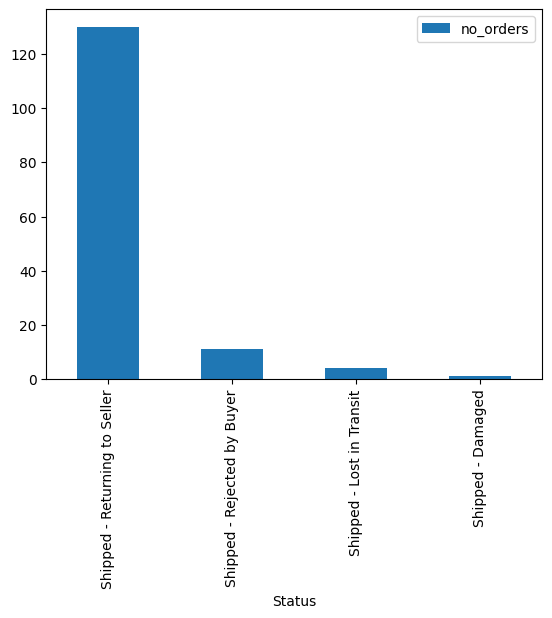

In [38]:
df_amazon_sales_not_completed.groupby("Status").agg(
    no_orders = ("Order ID", "nunique")
).sort_values(by="no_orders", ascending=False).plot(kind="bar")